# 02 — Power model (Stage 3)

This notebook computes battery power for every architecture point, averaged over the mode schedule: continuous R-R, a 12-lead capture every hour, and BSPM on demand.

**Two cases:**
* **As-built.** Every orchestrator is a THReaD SoC with its measured ~225 µW always-on floor (P-10).
* **Spec.** The orchestrator floor is unknown. The model solves for the largest floor per SoC that still fits the 0.5 mW battery budget. That limit is a chip-spec output.

Assumption IDs (for example P-10, B-02) refer to `ASSUMPTIONS.md`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import geometry as geo, power as pw, params
pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 90)
p = pw.P()
g = geo.Garment(C=p['torso_circ'], H=p['torso_height'], Cs=p['sleeve_circ'], Ls=p['sleeve_len'])
sites = geo.build_layout(g, 'ML', int(p['spares_per_site']))
D = geo.dist_matrix(g, sites); hub = geo.central_hub(g, sites); N = len(sites)
HUES = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948']
INK, MUTED = '#1f1f1e', '#6b6a64'
print(f"{N} sites; duty per mode:", {k: f"{v*100:.3f}%" for k, v in pw.duty(p).items()})
print(f"yarn energy {pw.e_yarn_per_m(p)*1e12:.0f} pJ per useful bit per m; ADC conversion {pw.p_adc_ch(p, 500)*1e6:.3f} uW/ch at 500 S/s")

74 sites; duty per mode: {'RR': '99.277%', '12L': '0.694%', 'BSPM': '0.029%'}
yarn energy 467 pJ per useful bit per m; ADC conversion 0.050 uW/ch at 500 S/s


## Validation (V-01, revised)

| Check | Type |
|---|---|
| Warchall '19 UWB TX increment | **predictive**. The bit rate comes from the ADC sampling rate, not from the reported power |
| Warchall '19 without UWB, Kuang '25, Dabbaghian '24 | accounting (their own component numbers summed) |
| SeisMote '20 battery life and radio share | plausibility (PPG and IMU power are not separable) |

In [2]:
rows = []
# Warchall: 12 ch, electrode IC 212 uW/ch, shared SAR 190 uW at 1.28 MS/s x 12 b, UWB 88 pJ/b
tx_pred = 1.28e6 * 12 * 88e-12 / 12 * 1e6
rows.append(('Warchall TX increment per ch [uW]', 340 - 228, tx_pred, 'predictive'))
rows.append(('Warchall per ch without UWB [uW]', 228, 212 + 190/12, 'accounting'))
rows.append(('Kuang total, 4 ch [uW]', 124, 4 * 30.93, 'accounting'))
rows.append(('Dabbaghian per AE [uW]', 17.5, 17.5, 'accounting only: not decomposable from reported data'))
life = 150 / 9.4
rows.append(('SeisMote battery life [h]', 16, life, 'plausibility: 150 mAh / 9.4 mA'))
radio_lo, radio_hi = 2.07e3*8 * 0.21e-6 * 1e3, 2.07e3*8 * 1.25e-6 * 1e3
rows.append(('SeisMote radio share of 34.8 mW [%]', float('nan'), f"{radio_lo/34.8*100:.0f}-{radio_hi/34.8*100:.0f}", 'plausibility: consistent with TX dominating'))
V = pd.DataFrame(rows, columns=['quantity', 'reported', 'model', 'type'])
V['error_%'] = [ (float(m) - r) / r * 100 if isinstance(m, float) and r == r else np.nan for _, r, m, _ in rows]
V.round(2)

,quantity,reported,model,type,error_%
0,Warchall TX increment per ch [uW],112.0,112.64,predictive,0.57
1,Warchall per ch without UWB [uW],228.0,227.833333,accounting,-0.07
2,"Kuang total, 4 ch [uW]",124.0,123.72,accounting,-0.23
3,Dabbaghian per AE [uW],17.5,17.5,accounting only: not decomposable from reported data,0.00
4,SeisMote battery life [h],16.0,15.957447,plausibility: 150 mAh / 9.4 mA,-0.27
5,SeisMote radio share of 34.8 mW [%],NaN,10-59,plausibility: consistent with TX dominating,NaN


## Sweep: every (m, n) point with mesh links, both cases

In [3]:
ms = [1, 2, 3, 4, 8, 16, N]; ns = [1, 2, 4, 8, N]
rows = []
for m in ms:
    for n in ns:
        pt = geo.build_point(g, sites, D, m, n, 'mesh', 'mesh', hub)
        a = pw.average_power(sites, D, pt, p, 'asbuilt')
        s0 = pw.average_power(sites, D, pt, p, 'spec', 0.0)
        rows.append(dict(m='N' if m == N else m, n='all' if n == N else n, nodes=pt.n_nodes, SoCs=pt.n_areas,
                         asbuilt_uW=a['total']*1e6, spec_at_0_uW=s0['total']*1e6,
                         max_floor_per_SoC_uW=pw.max_orch_floor(sites, D, pt, p)*1e6,
                         **{f'{k}_uW': s0[k]*1e6 for k in pw.CATS},
                         RR_uW=s0['mode_RR']*1e6, L12_uW=s0['mode_12L']*1e6, BSPM_uW=s0['mode_BSPM']*1e6))
R = pd.DataFrame(rows)
R.to_csv('power_sweep_mesh.csv', index=False)
R[['m','n','nodes','SoCs','asbuilt_uW','spec_at_0_uW','max_floor_per_SoC_uW','tx_uW','node_fixed_uW','node_off_uW','link_intra_uW','link_inter_uW']].round(1)

,m,n,nodes,SoCs,asbuilt_uW,spec_at_0_uW,max_floor_per_SoC_uW,tx_uW,node_fixed_uW,node_off_uW,link_intra_uW,link_inter_uW
0,1,1,74,74,23967.8,520.4,-0.2,47.2,69.6,50.0,0.0,5.6
1,1,2,74,37,12074.1,350.3,2.8,47.2,69.6,50.0,2.0,2.7
2,1,4,74,19,6288.7,268.4,8.5,49.5,69.6,50.0,1.1,1.6
3,1,8,74,10,3404.4,235.9,18.5,58.8,69.6,50.0,1.9,0.1
4,1,all,74,1,517.1,200.3,209.8,61.6,69.6,50.0,4.8,0.0
5,2,1,37,37,12007.9,284.1,4.1,47.2,35.4,25.0,0.0,0.6
6,2,2,37,19,6225.4,205.1,10.9,49.6,35.4,25.0,1.0,0.4
7,2,4,37,10,3337.4,168.9,23.2,54.3,35.4,25.0,1.5,0.1
8,2,8,37,5,1732.8,148.5,49.2,55.9,35.4,25.0,2.4,0.2
9,2,all,37,1,451.3,134.5,255.9,61.6,35.4,25.0,1.0,0.0


## Design map: allowed orchestrator floor per SoC (spec case) vs. as-built power

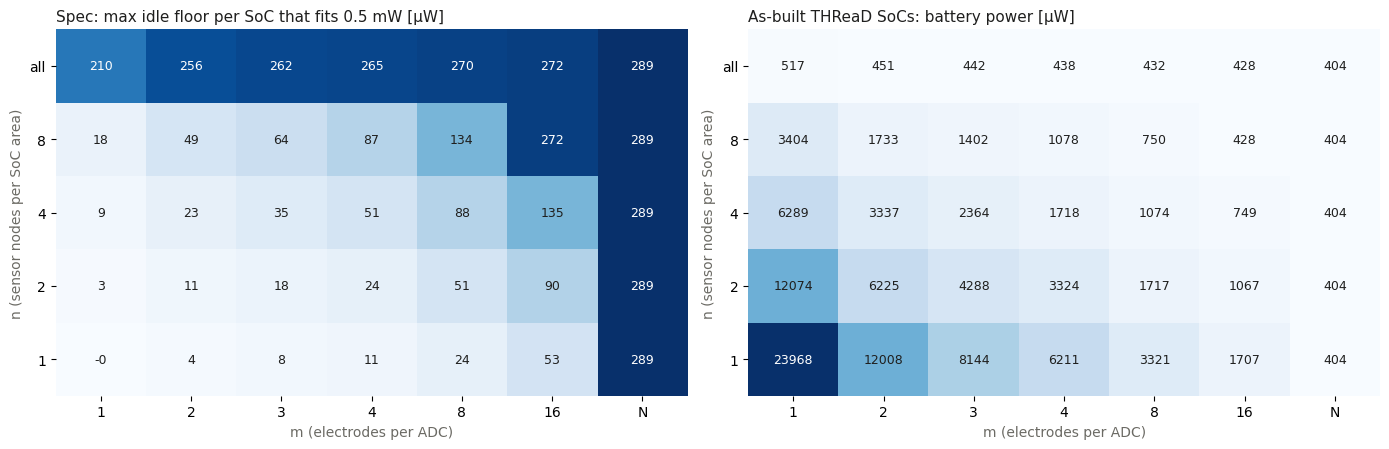

As-built THReaD floor = 225 uW per SoC; budget = 500 uW at the battery.


In [4]:
def grid(col):
    Z = np.array([[R[(R.m == (('N' if m == N else m))) & (R.n == ('all' if n == N else n))][col].values[0] for m in ms] for n in ns])
    return Z
mlab = [str(m) if m != N else 'N' for m in ms]; nlab = [str(n) if n != N else 'all' for n in ns]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, col, title, cmap, fmt in [
        (axes[0], 'max_floor_per_SoC_uW', 'Spec: max idle floor per SoC that fits 0.5 mW [µW]', 'Blues', '{:.0f}'),
        (axes[1], 'asbuilt_uW', 'As-built THReaD SoCs: battery power [µW]', 'Blues', '{:.0f}')]:
    Z = grid(col)
    im = ax.imshow(Z, cmap=cmap, aspect='auto', origin='lower')
    for i in range(len(ns)):
        for j in range(len(ms)):
            v = Z[i, j]
            ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=9,
                    color='white' if v > np.nanmax(Z) * 0.55 else INK)
    ax.set_xticks(range(len(ms)), mlab); ax.set_yticks(range(len(ns)), nlab)
    ax.set_xlabel('m (electrodes per ADC)', color=MUTED); ax.set_ylabel('n (sensor nodes per SoC area)', color=MUTED)
    ax.set_title(title, loc='left', fontsize=11, color=INK)
    for sp_ in ax.spines.values(): sp_.set_visible(False)
plt.tight_layout(); plt.savefig('design_map_power.png', dpi=160); plt.show()
print('As-built THReaD floor = 225 uW per SoC; budget = 500 uW at the battery.')

## Where the power goes (spec case, illustrative 10 µW orchestrator floor)

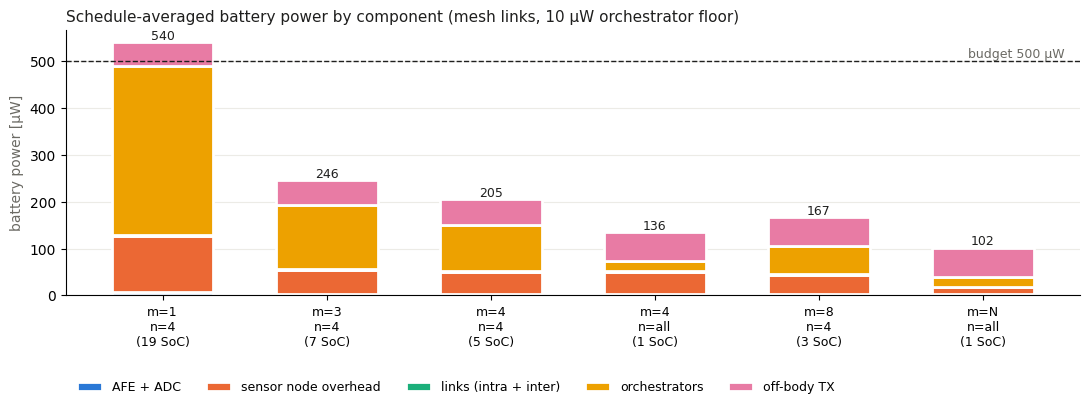

,m=1 n=4 (19 SoC),m=3 n=4 (7 SoC),m=4 n=4 (5 SoC),m=4 n=all (1 SoC),m=8 n=4 (3 SoC),m=N n=all (1 SoC)
AFE + ADC,6.4,3.5,3.5,3.5,3.5,3.5
sensor node overhead,119.5,51.6,47.3,47.3,40.5,14.3
links (intra + inter),2.7,1.5,0.8,0.9,1.1,0.0
orchestrators,361.6,135.4,97.6,22.2,59.9,22.2
off-body TX,49.5,54.4,55.9,61.6,61.6,61.6


In [5]:
FLOOR = 10e-6   # illustration only (logged as X-06); not a measured value
pick = [(1, 4), (3, 4), (4, 4), (4, N), (8, 4), (N, N)]
groups = {'AFE + ADC': ['afe_adc'], 'sensor node overhead': ['node_fixed', 'node_off'],
          'links (intra + inter)': ['link_intra', 'link_inter'], 'orchestrators': ['orch_floor', 'orch_compute'],
          'off-body TX': ['tx']}
bars = []
for m, n in pick:
    pt = geo.build_point(g, sites, D, m, n, 'mesh', 'mesh', hub)
    a = pw.average_power(sites, D, pt, p, 'spec', FLOOR)
    bars.append((f"m={m if m != N else 'N'}\nn={n if n != N else 'all'}\n({pt.n_areas} SoC)", {k: sum(a[c] for c in v)*1e6 for k, v in groups.items()}))
fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(len(bars)); bottom = np.zeros(len(bars))
for gi, gname in enumerate(groups):
    vals = np.array([b[1][gname] for b in bars])
    ax.bar(x, vals, bottom=bottom, color=HUES[gi], width=0.62, edgecolor='white', linewidth=2, label=gname)
    bottom += vals
for xi, tot in zip(x, bottom):
    ax.text(xi, tot + 6, f"{tot:.0f}", ha='center', fontsize=9, color=INK)
ax.axhline(p['P_budget']*1e3, color=INK, lw=1, ls='--'); ax.text(len(bars)-0.5, p['P_budget']*1e3 + 8, 'budget 500 µW', ha='right', fontsize=9, color=MUTED)
ax.set_xticks(x, [b[0] for b in bars], fontsize=9); ax.set_ylabel('battery power [µW]', color=MUTED)
ax.set_title('Schedule-averaged battery power by component (mesh links, 10 µW orchestrator floor)', loc='left', fontsize=11, color=INK)
ax.legend(frameon=False, fontsize=9, ncol=5, loc='upper left', bbox_to_anchor=(0, -0.28))
for sp_ in ('top', 'right'): ax.spines[sp_].set_visible(False)
ax.grid(axis='y', color='#ecebe6'); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig('power_breakdown.png', dpi=160); plt.show()
pd.DataFrame({b[0].replace(chr(10), ' '): b[1] for b in bars}).round(1)

## Sensitivity (m = 4, n = 4, spec case at a 10 µW floor): each parameter swept over its logged range

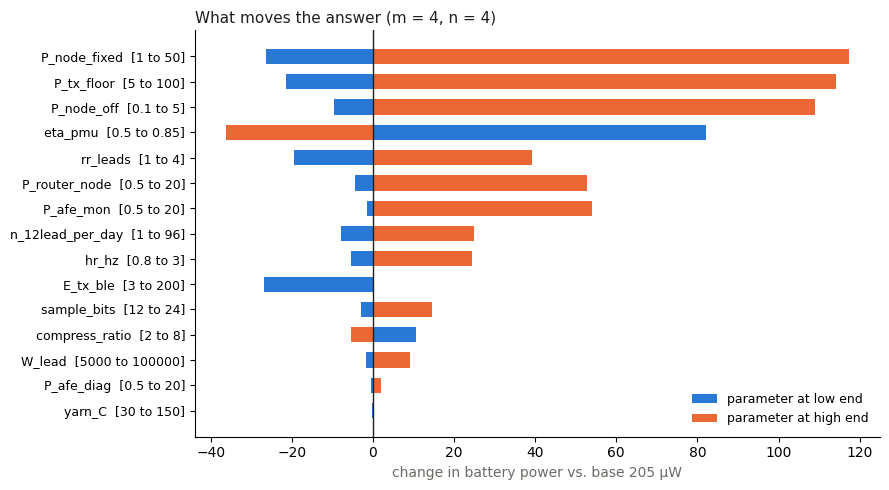

,param,low,high,d_low_uW,d_high_uW
5,P_node_fixed,1.0,50.0,-26.4,117.3
1,P_tx_floor,5.0,100.0,-21.4,114.3
7,P_node_off,0.1,5.0,-9.7,108.9
4,eta_pmu,0.5,0.8,82.1,-36.2
13,rr_leads,1.0,4.0,-19.5,39.3
6,P_router_node,0.5,20.0,-4.4,52.8
8,P_afe_mon,0.5,20.0,-1.4,53.9
2,n_12lead_per_day,1.0,96.0,-8.0,25.0
12,hr_hz,0.8,3.0,-5.4,24.5
0,E_tx_ble,3.0,200.0,-26.9,0.0


In [6]:
pt44 = geo.build_point(g, sites, D, 4, 4, 'mesh', 'mesh', hub)
base = pw.average_power(sites, D, pt44, p, 'spec', FLOOR)['total'] * 1e6
t = params.table()
names = ['E_tx_ble', 'P_tx_floor', 'n_12lead_per_day', 'compress_ratio', 'eta_pmu', 'P_node_fixed', 'P_router_node',
         'P_node_off', 'P_afe_mon', 'P_afe_diag', 'yarn_C', 'W_lead', 'hr_hz', 'rr_leads', 'sample_bits']
rows = []
for nm in names:
    lo, hi = t.loc[nm, 'low'], t.loc[nm, 'high']
    vlo = pw.average_power(sites, D, pt44, dict(p, **{nm: lo}), 'spec', FLOOR)['total'] * 1e6
    vhi = pw.average_power(sites, D, pt44, dict(p, **{nm: hi}), 'spec', FLOOR)['total'] * 1e6
    rows.append((nm, lo, hi, vlo - base, vhi - base))
T = pd.DataFrame(rows, columns=['param', 'low', 'high', 'd_low_uW', 'd_high_uW'])
T['span'] = (T.d_high_uW - T.d_low_uW).abs(); T = T.sort_values('span')
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(T))
ax.barh(y, T.d_low_uW, color=HUES[0], height=0.6, label='parameter at low end')
ax.barh(y, T.d_high_uW, color=HUES[1], height=0.6, label='parameter at high end')
ax.set_yticks(y, [f"{r.param}  [{r.low:g} to {r.high:g}]" for r in T.itertuples()], fontsize=9)
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel(f'change in battery power vs. base {base:.0f} µW', color=MUTED)
ax.set_title('What moves the answer (m = 4, n = 4)', loc='left', fontsize=11, color=INK)
ax.legend(frameon=False, fontsize=9, loc='lower right')
for sp_ in ('top', 'right'): ax.spines[sp_].set_visible(False)
plt.tight_layout(); plt.savefig('sensitivity_m4n4.png', dpi=160); plt.show()
T.drop(columns='span').round(1).iloc[::-1]

## Reference: an off-the-shelf AFE (ADS1292R at 335 µW/ch) in the same architectures

In [7]:
pc = dict(p, P_afe_diag=335, P_afe_mon=335, P_node_fixed=0, adc_fom=0)   # the ADS1292R figure already includes its ADC and digital
rows = []
for m, n in [(4, 4), (N, N)]:
    pt = geo.build_point(g, sites, D, m, n, 'mesh', 'mesh', hub)
    rows.append((f"m={m if m != N else 'N'}, n={n if n != N else 'all'}",
                 pw.average_power(sites, D, pt, pc, 'spec', FLOOR)['total']*1e6,
                 pw.average_power(sites, D, pt, p, 'spec', FLOOR)['total']*1e6))
pd.DataFrame(rows, columns=['architecture', 'COTS AFE [uW]', 'custom AFE [uW]']).round(0)

,architecture,COTS AFE [uW],custom AFE [uW]
0,"m=4, n=4",1165.0,205.0
1,"m=N, n=all",1073.0,102.0


## Findings (ML layout, 1 spare per site, mesh links, export = on-body where capacity allows; revised 2026-10-01)

**Revision note.** This version fixes a bug: captures were previously streamed during the 15 s warm-up, which inflated TX. It also adds retained-SRAM leakage (0.1 µW/kB × 32 kB per SoC) and the capacity-limited on-body export policy. Together these lower the spec-case totals by about 5–20 µW and TX from 87 to about 50–62 µW.

1. **Validation is unchanged.** Warchall's UWB TX is predicted to within 0.6%, and the accounting checks agree to within 0.3%.
2. **As-built THReaD orchestrators fit only as a single SoC** (404–517 µW). Multi-area designs are 1.3–48× over budget; m = 4, n = 4 needs 1.72 mW.
3. **Allowed core floor per SoC (the chip-spec map):**
   * m = 4, n = 4: ≤ 51 µW
   * m = 4, n = 8: ≤ 87 µW
   * m = 4, n = 1: ≤ 11 µW
   * m = 1, n = 4: ≤ 8.5 µW
   * Each of these comes on top of 3.2 µW of SRAM retention.
   * m = 1, n = 1 (74 SoCs) is infeasible at any floor.
4. **Links are negligible for the default, rhythm-dominated schedule** (≤ 6 µW). They become first-order in continuous high-channel streaming (Stage 3 correction).
5. **On power alone, centralization wins for the default schedule.** At a zero core floor, centralized needs 87 µW against 121–134 µW for m = 4.
6. **Off-body TX is about 50–62 µW at 200 nJ/b** (BLE connection floor, R-R features and captures). After the radio range was widened to 3–200 nJ/b (2026-10-01), the default schedule is most sensitive to sensor-node overhead, the BLE connection floor and off-state power; radio energy itself moves the total by at most 27 µW. On-body capture analysis saves at most about 12 µW under this schedule (notebook 04). Radio energy matters most for continuous morphology monitoring (notebook 07).
7. **Chiplet gating is a spec item.** Raising off-state power from 0.5 to 5 µW adds 109 µW, and raising node overhead from 10 to 50 µW adds 117 µW.
8. **An off-the-shelf AFE doesn't fit.** ADS1292R-class channels bring the total to about 1.1–1.2 mW.
